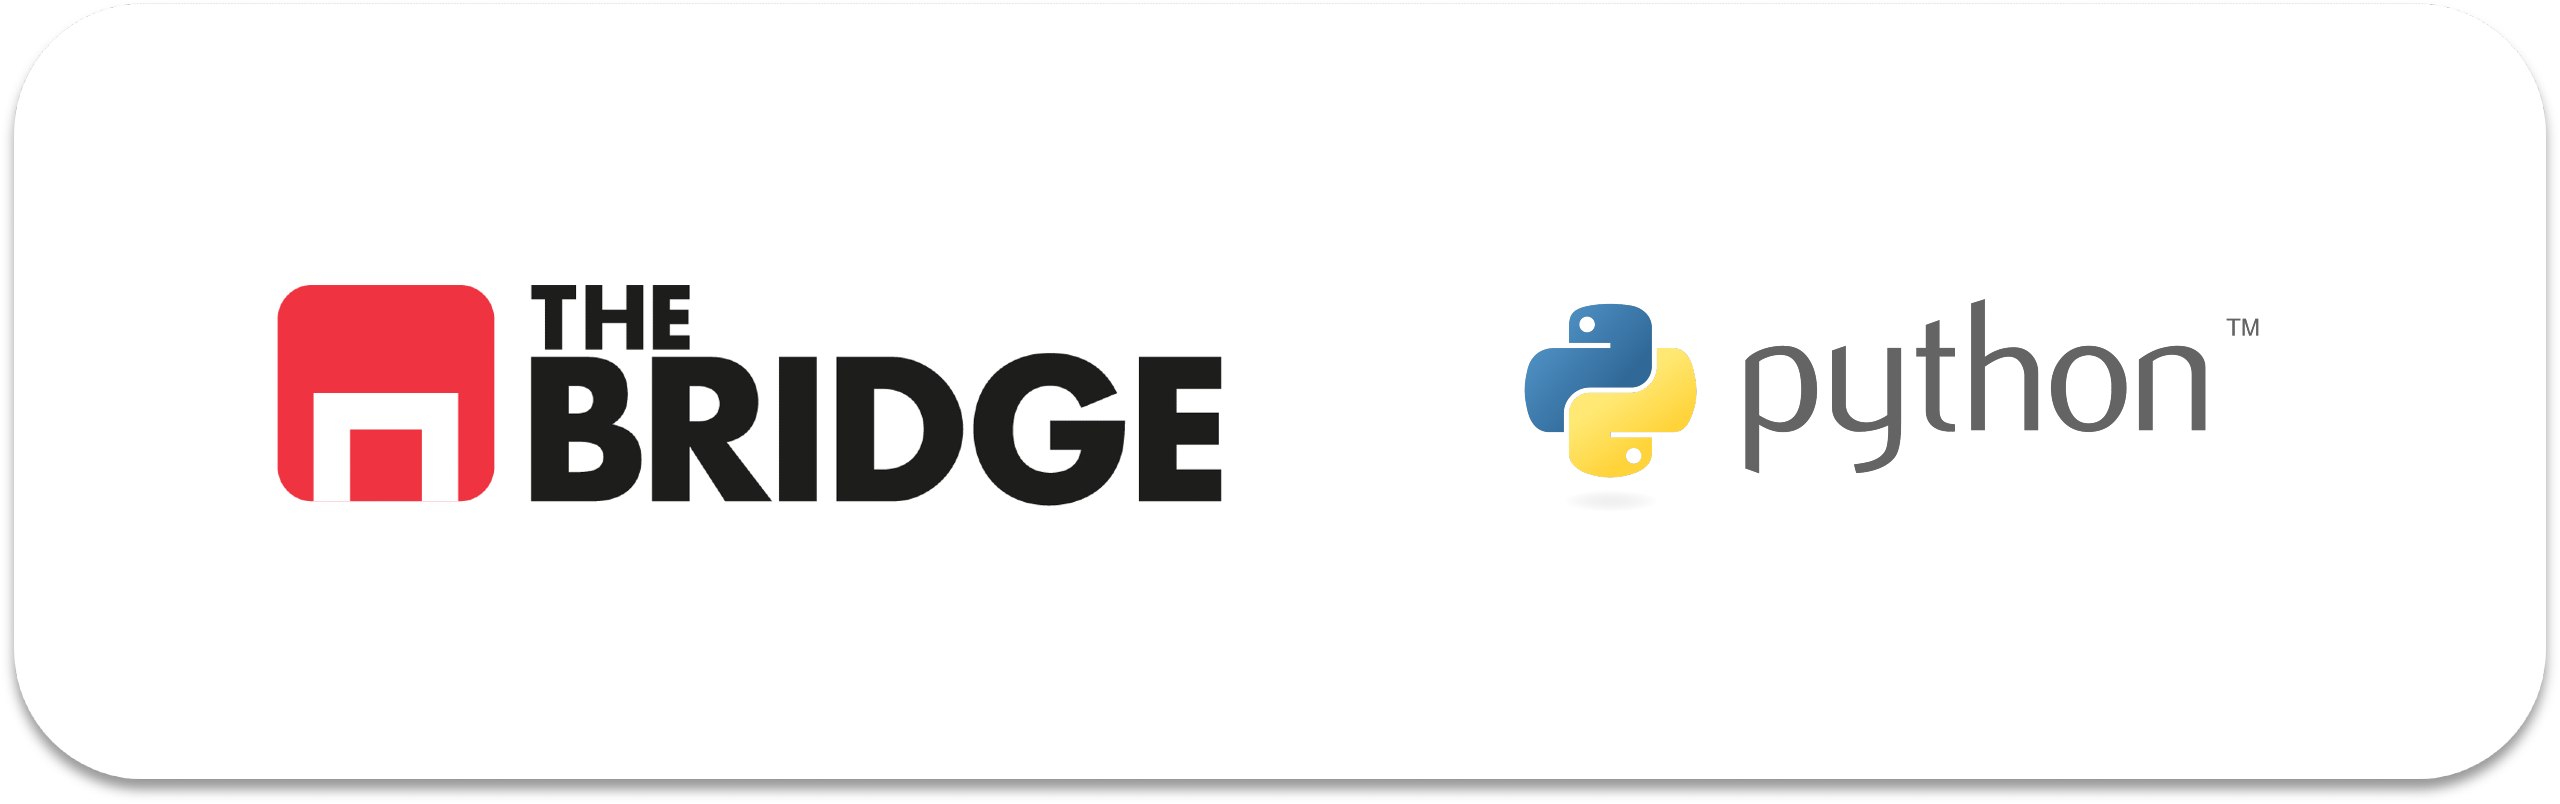



# Entornos Virtuales en Python

---

## Índice

1. [¿Qué es un entorno virtual y por qué lo necesitas?](#1-qué-es-un-entorno-virtual-y-por-qué-lo-necesitas)
2. [Crear y activar un entorno con `venv`](#2-crear-y-activar-un-entorno-con-venv)
3. [Instalar paquetes en el entorno](#3-instalar-paquetes-en-el-entorno)
4. [Gestión de dependencias con `requirements.txt`](#4-gestión-de-dependencias-con-requirementstxt)
5. [Entornos virtuales y Git](#5-entornos-virtuales-y-git)
6. [Versiones específicas de Python](#6-versiones-específicas-de-python)
7. [Alternativas: conda, virtualenv, pyenv](#7-alternativas-conda-virtualenv-pyenv)
8. [Ejercicios](#8-ejercicios)


---
## 1. ¿Qué es un entorno virtual y por qué lo necesitas?

Sin entorno virtual, todos los paquetes que instalas con `pip` van al **Python global** de tu sistema. Dos proyectos que necesiten versiones distintas del mismo paquete entran en conflicto.

```
Sistema global:
  numpy 1.21   ← Proyecto A lo necesita así
  numpy 1.26   ← Proyecto B lo necesita así
  ¿cuál gana? 💥
```

Un entorno virtual crea un **espacio aislado** con su propio intérprete de Python y sus propios paquetes:

```
proyecto-a/
  .venv/          ← numpy 1.21, pandas 1.3, ...
proyecto-b/
  .venv/          ← numpy 1.26, scikit-learn 1.4, ...
```

> 🧑‍🍳 **Analogía:** es como tener despensas separadas para cada receta. El sofrito de la paella no interfiere con los ingredientes del tiramisú.

### Ventajas clave

- **Reproducibilidad**: cualquiera puede recrear el entorno exacto
- **Aislamiento**: instalar o actualizar en un proyecto no rompe otro
- **Limpieza**: el Python global permanece sin contaminar
- **Profesionalidad**: es el estándar en cualquier equipo de desarrollo


---
## 2. Crear y activar un entorno con `venv`

`venv` es el módulo estándar de Python (desde Python 3.3) para crear entornos virtuales. No necesitas instalar nada extra.

### Crear el entorno

```bash
# macOS / Linux
python3 -m venv .venv

# Windows
python -m venv .venv
```

> 💡 Por convención se llama `.venv` (con punto, para que quede oculto en el explorador). Puedes llamarlo como quieras.

Esto crea una carpeta `.venv/` con su propio intérprete de Python y una copia de `pip`.

---

### Activar el entorno

Hay que activar el entorno **cada vez que abras una nueva terminal**.

| Sistema | Comando |
|---------|---------|
| macOS / Linux | `source .venv/bin/activate` |
| Windows (GitBash) | `source .venv/Scripts/activate` |
| Windows (CMD) | `.venv\Scripts\activate.bat` |
| Windows (PowerShell) | `.venv\Scripts\Activate.ps1` |

Al activarlo, el prompt cambia para indicarlo:

```
(.venv) usuario@maquina:~/mi-proyecto$
```

Ese `(.venv)` delante confirma que estás dentro del entorno.

---

### Verificar que funciona

```bash
which python3          # macOS/Linux → apunta a .venv/bin/python3
where python           # Windows
python3 --version      # la versión del entorno
pip list               # paquetes instalados — casi vacío al principio
```

---

### Desactivar el entorno

```bash
deactivate
```

El prompt vuelve a la normalidad. Cualquier paquete que instales ahora va al global.

---

> ⚠️ **Error de PowerShell en Windows**
> Si ves *"la ejecución de scripts está deshabilitada"*, ejecuta en PowerShell:
> ```powershell
> Set-ExecutionPolicy RemoteSigned -Scope CurrentUser
> ```
> O simplemente **usa GitBash** y olvídate del problema 🙂


---
## 3. Instalar paquetes en el entorno

Con el entorno **activado**, `pip install` instala únicamente dentro del entorno:

```bash
pip install requests
pip install numpy pandas matplotlib
pip install scikit-learn==1.4.0   # versión específica
```

Comprueba que el paquete está solo en el entorno:

```bash
pip list                  # lista paquetes del entorno activo
pip show requests         # info de un paquete concreto
```

---

### Desinstalar un paquete

```bash
pip uninstall requests
```

---

### Actualizar un paquete

```bash
pip install --upgrade numpy
```

---

> 🔑 **Regla de oro:** siempre activa el entorno antes de instalar. Si no ves `(.venv)` en el prompt, el paquete irá al global.


---
## 4. Gestión de dependencias con `requirements.txt`

Un archivo `requirements.txt` documenta **exactamente** qué paquetes (y en qué versión) necesita tu proyecto. Es lo que compartes con el equipo en lugar del entorno virtual.

---

### Generar el fichero

Con el entorno activado y los paquetes ya instalados:

```bash
pip freeze > requirements.txt
```

El fichero resultante tiene este aspecto:

```
numpy==1.26.4
pandas==2.2.1
requests==2.31.0
scikit-learn==1.4.2
```

---

### Instalar desde el fichero

Cualquier compañere clona el repo y hace:

```bash
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
```

Y tiene el entorno idéntico al tuyo.

---

### Buenas prácticas con `requirements.txt`

```bash
# Especificar versión exacta (máxima reproducibilidad)
numpy==1.26.4

# Aceptar cualquier parche (más flexible)
numpy>=1.26,<2.0

# Comentar la versión de Python usada
# Python 3.11.8
numpy==1.26.4
pandas==2.2.1
```

> 💬 En proyectos de producción se recomienda versiones exactas (`==`).  
> En proyectos de aprendizaje o librerías, a veces se usan rangos (`>=`).


---
## 5. Entornos virtuales y Git

El entorno virtual **nunca se sube al repositorio**. Puede pesar cientos de MB y es específico de cada sistema operativo.

Lo que sí se sube: el `requirements.txt`.

---

### Configurar `.gitignore`

Crea o edita el `.gitignore` en la raíz del proyecto:

```gitignore
# Entornos virtuales
.venv/
venv/
env/
.env/
ENV/

# Conda
.conda/
```

---

### Flujo completo con Git

```bash
# 1. Crear el proyecto
mkdir mi-proyecto && cd mi-proyecto
git init

# 2. Crear y activar el entorno
python3 -m venv .venv
source .venv/bin/activate

# 3. Instalar dependencias
pip install numpy pandas

# 4. Documentar dependencias
pip freeze > requirements.txt

# 5. Ignorar el entorno, subir el requirements
echo ".venv/" >> .gitignore
git add .gitignore requirements.txt
git commit -m "feat: add requirements and gitignore"
git push
```

---

### ¿Qué hace el compañero al clonar?

```bash
git clone <url>
cd mi-proyecto
python3 -m venv .venv
source .venv/bin/activate
pip install -r requirements.txt
# ✅ Entorno idéntico
```

> 📦 Regla de oro: `.venv/` en el `.gitignore`, `requirements.txt` en el repo.


---
## 6. Versiones específicas de Python

A veces un proyecto necesita una versión concreta de Python (no la que tienes por defecto).

---

### Opción A: ejecutable directo (si lo tienes instalado)

```bash
# macOS / Linux
python3.10 -m venv .venv
python3.11 -m venv .venv

# Windows
py -3.10 -m venv .venv
py -3.11 -m venv .venv
```

---

### Opción B: pyenv (recomendado para macOS/Linux)

`pyenv` permite instalar y gestionar varias versiones de Python en la misma máquina:

```bash
# Instalar pyenv (una sola vez)
brew install pyenv          # macOS
curl https://pyenv.run | bash   # Linux

# Instalar una versión de Python
pyenv install 3.10.14

# Usarla en un proyecto concreto
cd mi-proyecto
pyenv local 3.10.14         # crea .python-version en el directorio

# Crear el entorno con esa versión
python -m venv .venv
python --version            # → 3.10.14
```

---

### Verificar la versión del entorno

```bash
source .venv/bin/activate
python --version   # → Python 3.10.14
```

> 💡 Documenta la versión de Python en el `README` o al inicio del `requirements.txt`:
> ```
> # Python 3.10.14
> numpy==1.26.4
> ...
> ```


---
## 7. Alternativas: conda, virtualenv, pyenv

| Herramienta | Cuándo usarla | Cómo se usa |
|-------------|---------------|-------------|
| **venv** | Proyectos Python puro — la opción estándar, sin instalar nada extra | `python3 -m venv .venv` |
| **conda** | Data science / IA — gestiona dependencias C/C++ y múltiples lenguajes | `conda create -n mi_entorno python=3.11` |
| **virtualenv** | Legacy — era el estándar antes de Python 3.3, hoy casi no se usa | `virtualenv mi_entorno` |
| **pyenv** | Gestión de versiones de Python — úsalo junto a venv | `pyenv install 3.10.14` |


---
## 8. Ejercicios

### Ejercicio 1 — Tu primer entorno virtual

1. Crea una carpeta `proyecto-demo` y entra en ella.
2. Crea un entorno virtual llamado `.venv`.
3. Actívalo y verifica con `pip list` que está vacío.
4. Instala `requests` y `httpx`.
5. Genera el `requirements.txt`.
6. Desactívalo.

---

### Ejercicio 2 — Reproducir un entorno

Simula el flujo de un compañere que recibe tu proyecto:

1. Crea una carpeta `proyecto-colega`.
2. Crea y activa un nuevo entorno virtual.
3. Instala las dependencias usando el `requirements.txt` que generaste en el ejercicio anterior.
4. Verifica con `pip list` que tiene los mismos paquetes.

---

### Ejercicio 3 — Entornos y Git

1. Inicializa un repositorio Git en `proyecto-demo`.
2. Crea un `.gitignore` que excluya `.venv/`.
3. Haz un commit con `requirements.txt` y `.gitignore` (y solo esos dos ficheros).
4. Verifica con `git status` que `.venv/` no aparece como fichero a seguir.
